# 02 — Эксперименты: выбор модели

Сравнение прототипов на **подвыборке** (~20k CVE). Финальная модель для API обучается отдельно: `python -m src.train`.

Перед запуском: `python -m src.data`

In [1]:
import sys
from pathlib import Path
for p in [Path.cwd(), Path.cwd().parent]:
    if (p / "src").exists():
        sys.path.insert(0, str(p.resolve()))
        break

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import learning_curve, train_test_split

from src.data.load_nvd import load_processed_dataset
from src.features.text import clean_description
from src.models.pipelines import build_experiment_models
from src.utils.config import load_config, resolve_path

cfg = load_config()
RANDOM_STATE = int(cfg["model"]["random_state"])
TEST_SIZE = float(cfg["model"]["test_size"])
EXPERIMENT_N = int(cfg["model"]["experiment_sample_size"])
PRODUCTION_NAME = str(cfg["model"]["production_model"])

FIGURES = resolve_path(cfg["artifacts"]["figures_dir"])
FIGURES.mkdir(parents=True, exist_ok=True)
ARTIFACTS = resolve_path(cfg["artifacts"]["dir"])
sns.set_theme(style="whitegrid")
LABEL_NAMES = ["low", "medium", "high"]

In [2]:
df = load_processed_dataset()
max_len = int(cfg["data"]["max_text_len"])
print("Полный датасет:", df.shape)
print(df["severity"].value_counts())

Полный датасет: (78040, 6)
severity
high      38675
medium    37556
low        1809
Name: count, dtype: int64


In [ ]:
# Подвыборка для экспериментов
exp_n = min(EXPERIMENT_N, len(df))
idx_exp, _ = train_test_split(
    df.index,
    train_size=exp_n,
    random_state=RANDOM_STATE,
    stratify=df["severity_id"],
)
exp_df = df.loc[idx_exp].copy()

texts_exp = exp_df["description"].map(lambda t: clean_description(t, max_len))
y_exp = exp_df["severity_id"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    texts_exp, y_exp, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_exp
)
print("Подвыборка:", len(exp_df), "| train/test:", len(X_train), "/", len(X_test))

Подвыборка: 20000 | train/test: 16000 / 4000


In [4]:
models = build_experiment_models(cfg)
list(models.keys())

['DummyClassifier',
 'LogisticRegression',
 'SGDClassifier',
 'RandomForestClassifier']

In [5]:
metrics_all = {}
preds_test = {}

for name, pipe in models.items():
    print("Обучение:", name)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)
    preds_test[name] = y_pred
    metrics_all[name] = {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
        "mcc": float(matthews_corrcoef(y_test, y_pred)),
        "roc_auc": float(
            roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted", labels=[0, 1, 2])
        ),
    }

pd.DataFrame(metrics_all).T.round(4)

Обучение: DummyClassifier


Обучение: LogisticRegression


Обучение: SGDClassifier


Обучение: RandomForestClassifier


,accuracy,f1,f1_weighted,balanced_accuracy,mcc,roc_auc
DummyClassifier,0.4955,0.2209,0.3283,0.3333,0.0000,0.5000
LogisticRegression,0.7742,0.6170,0.7797,0.6512,0.5761,0.8833
SGDClassifier,0.7822,0.6095,0.7815,0.6056,0.5822,0.8811
RandomForestClassifier,0.8060,0.5759,0.7983,0.5670,0.6222,0.8969


In [6]:
metrics_path = ARTIFACTS / cfg["artifacts"]["metrics_all_file"]
with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics_all, f, ensure_ascii=False, indent=2)
print("Сохранено:", metrics_path)

best_by_f1 = max(metrics_all, key=lambda k: metrics_all[k]["f1"])
print("Лучший macro F1 на подвыборке:", best_by_f1)
print("Модель для API (config):", PRODUCTION_NAME)

Сохранено: C:\Users\Mi\aie_home\aie_repos\project\artifacts\metrics_all.json
Лучший macro F1 на подвыборке: LogisticRegression
Модель для API (config): LogisticRegression


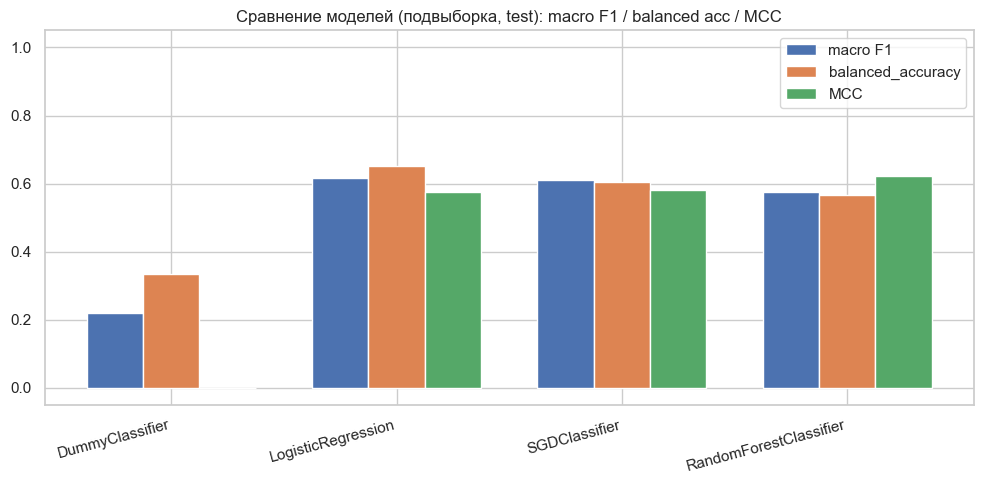

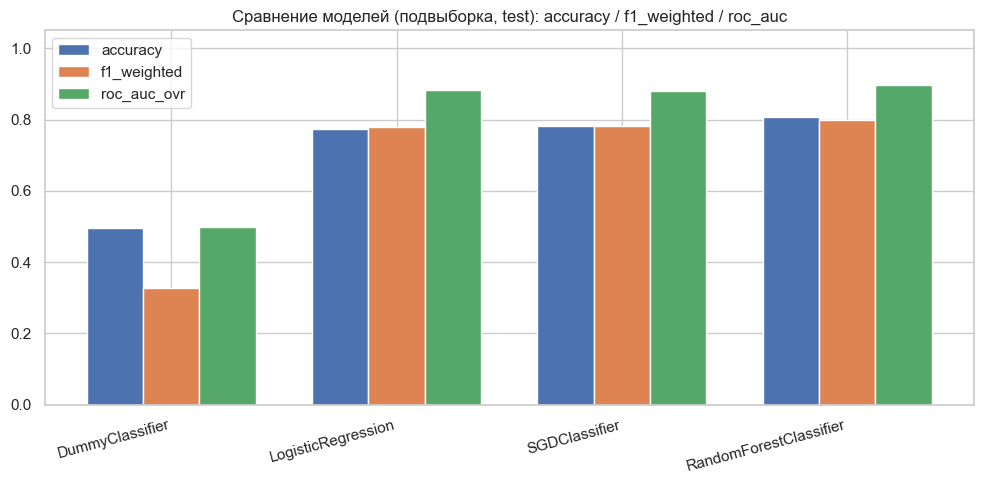

In [ ]:
# model_comparison.png — ключевые метрики
cmp = pd.DataFrame(metrics_all).T.reset_index().rename(columns={"index": "model"})
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cmp))
w = 0.25
ax.bar(x - w, cmp["f1"], width=w, label="macro F1")
ax.bar(x, cmp["balanced_accuracy"], width=w, label="balanced_accuracy")
ax.bar(x + w, cmp["mcc"], width=w, label="MCC")
ax.set_xticks(x)
ax.set_xticklabels(cmp["model"], rotation=15, ha="right")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Сравнение моделей: macro F1 / balanced acc / MCC")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "model_comparison.png", dpi=120)
plt.show()

# model_comparison_secondary.png — дополнительные метрики
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, cmp["accuracy"], width=w, label="accuracy")
ax.bar(x, cmp["f1_weighted"], width=w, label="f1_weighted")
ax.bar(x + w, cmp["roc_auc"], width=w, label="roc_auc_ovr")
ax.set_xticks(x)
ax.set_xticklabels(cmp["model"], rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Сравнение моделей: accuracy / f1_weighted / roc_auc")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "model_comparison_secondary.png", dpi=120)
plt.show()

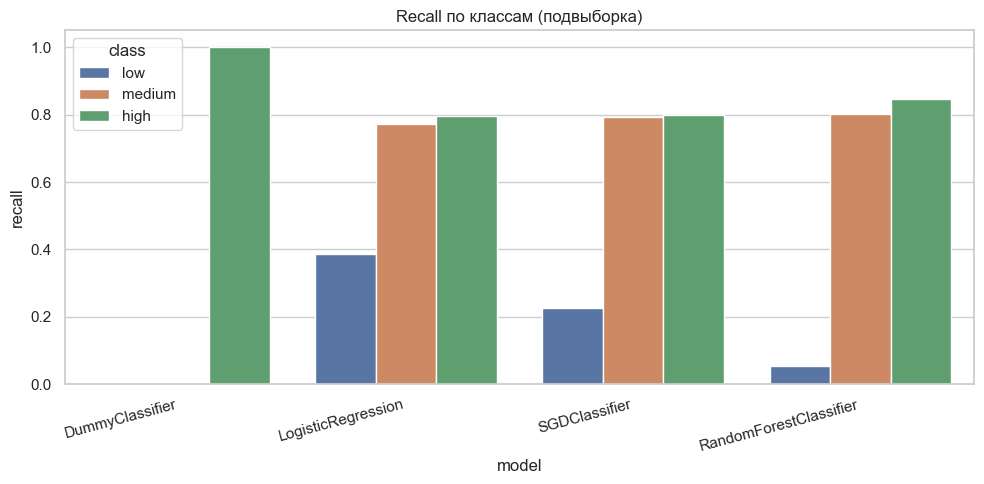

In [ ]:
# per_class_recall.png
rows = []
for name, y_pred in preds_test.items():
    recalls = recall_score(y_test, y_pred, average=None, zero_division=0, labels=[0, 1, 2])
    for cls_id, cls_name in enumerate(LABEL_NAMES):
        rows.append({"model": name, "class": cls_name, "recall": recalls[cls_id]})
rec_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=rec_df, x="model", y="recall", hue="class", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Recall по классам")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "per_class_recall.png", dpi=120)
plt.show()

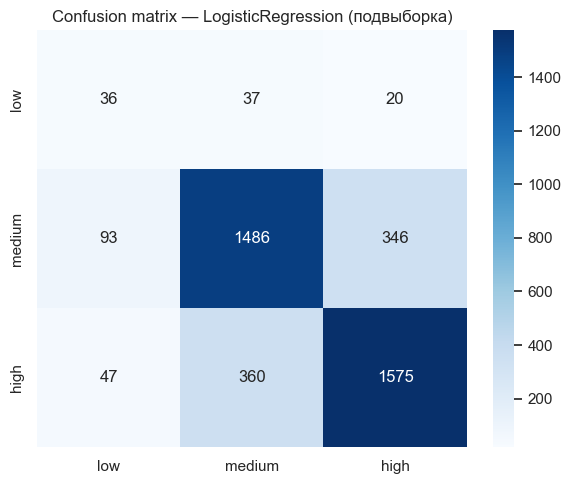

In [ ]:
# confusion_matrix для выбранной в config модели (на подвыборке)
y_pred_prod = preds_test[PRODUCTION_NAME]
cm = confusion_matrix(y_test, y_pred_prod, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_title(f"Confusion matrix — {PRODUCTION_NAME} (подвыборка)")
plt.tight_layout()
plt.savefig(FIGURES / "confusion_matrix_logreg.png", dpi=120)
plt.show()

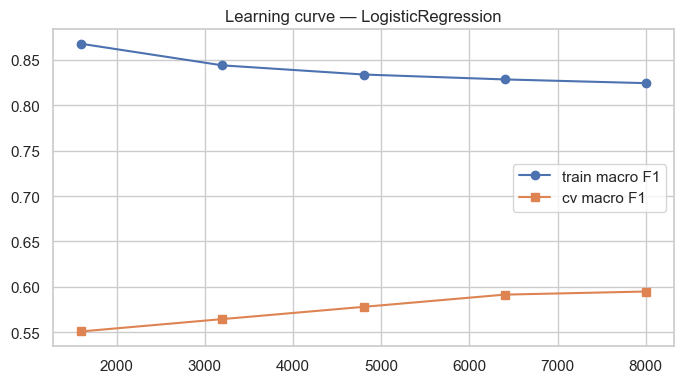

In [ ]:
# learning_curve для LogisticRegression
lc_pipe = models["LogisticRegression"]
sizes, train_scores, test_scores = learning_curve(
    lc_pipe, X_train, y_train, train_sizes=np.linspace(0.2, 1.0, 5),
    cv=2, scoring="f1_macro", n_jobs=-1, random_state=RANDOM_STATE,
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, train_scores.mean(axis=1), marker="o", label="train macro F1")
ax.plot(sizes, test_scores.mean(axis=1), marker="s", label="cv macro F1")
ax.set_title("Learning curve — LogisticRegression")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "learning_curve_logreg.png", dpi=120)
plt.show()

## Выбор модели для проекта

- Эксперименты проведены на подвыборке; метрики: `artifacts/metrics_all.json`.
- По **macro F1** и **balanced_accuracy** на подвыборке лучше всего выступает **LogisticRegression** (см. график `model_comparison.png`).
- **RandomForest** даёт более высокий `accuracy`/`mcc`, но заметно хуже по macro F1 и тяжелее для production (скорость/размер артефакта).
- Для API оставляем **LogisticRegression** (`production_model` в `configs/config.yaml`): стабильный баланс качества и скорости.
- **Следующий шаг:** обучить финальную модель на полном датасете:
  ```bash
  python -m src.train
  ```
  Будут созданы `artifacts/cve_model.joblib` и `artifacts/best_model.json`.